In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [110]:
country_list = pd.read_csv("C:\\heroku\\median-tariff\\data\\country-list-20.csv", header=None, names=["CTY_CODE"])

figfile = "C:\\github\\how-restrictive-us-trade\\figures\\"

texfile = "C:\\github\\how-restrictive-us-trade\\results.tex"

tabletex = "C:\\github\\how-restrictive-us-trade\\table-sector.tex"

In [89]:
file = f"C:\\heroku\\median-tariff\\data\\imports-hs10\\TOTALdata-current.parquet"

# Load country data
dfcntry = pq.read_table(file).to_pandas()

dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

dfcntry["HS2"] = dfcntry["I_COMMODITY"].astype(str).str[:2]

dfcntry = dfcntry[dfcntry["time"].dt.year == 2024]

grp = dfcntry.groupby(["HS2"])

bar = grp["CON_VAL_MO"].sum().reset_index()

bar["share"] = bar["CON_VAL_MO"] / bar["CON_VAL_MO"].sum()

bar = bar[~bar["HS2"].isin(["99", "98", "27", "71"])]

top_products = bar.sort_values(by="CON_VAL_MO", ascending=False).iloc[:10]
        
top_products.reset_index(inplace = True, drop= True)

top_20products = bar.sort_values(by="CON_VAL_MO", ascending=False).iloc[:20]
        
top_20products.reset_index(inplace = True, drop= True)

In [91]:
top_20products.head(20)

,HS2,CON_VAL_MO,share
0,84,5.141707e+11,0.158148
1,85,4.724788e+11,0.145325
2,87,3.889971e+11,0.119647
3,30,2.170696e+11,0.066766
4,90,1.226410e+11,0.037722
5,39,7.290455e+10,0.022424
6,94,6.704303e+10,0.020621
7,29,5.677369e+10,0.017462
8,73,4.939431e+10,0.015193
9,61,4.589008e+10,0.014115


In [115]:
# Dictionary mapping HS2 codes to product names
hs2_names = {
    '01': 'Live Animals',
    '02': 'Meat',
    '03': 'Fish',
    '04': 'Dairy Products',
    '05': 'Animal Products',
    '06': 'Live Plants',
    '07': 'Vegetables',
    '08': 'Fruit \& Nuts',
    '09': 'Coffee, Tea \& Spices',
    '10': 'Cereals',
    '11': 'Milling Products',
    '12': 'Oil Seeds',
    '13': 'Vegetable Extracts',
    '14': 'Vegetable Plaiting Materials',
    '15': 'Animal/Vegetable Fats',
    '16': 'Prepared Meat/Fish',
    '17': 'Sugars',
    '18': 'Cocoa Products',
    '19': 'Prepared Cereals',
    '20': 'Prepared Vegetables/Fruit',
    '21': 'Miscellaneous Food',
    '22': 'Beverages \& Vinegar',
    '23': 'Food Industry Waste',
    '24': 'Tobacco',
    '25': 'Salt, Sulfur \& Minerals',
    '26': 'Ores',
    '27': 'Mineral Fuels \& Oils',
    '28': 'Inorganic Chemicals',
    '29': 'Organic Chemicals',
    '30': 'Pharmaceuticals',
    '31': 'Fertilizers',
    '32': 'Dyes \& Paints',
    '33': 'Perfumes \& Cosmetics',
    '34': 'Soap \& Cleaning Products',
    '35': 'Protein Substances',
    '36': 'Explosives',
    '37': 'Photographic Goods',
    '38': 'Miscellaneous Chemicals',
    '39': 'Plastics',
    '40': 'Rubber',
    '41': 'Raw Hides \& Skins',
    '42': 'Leather Articles',
    '43': 'Furskins',
    '44': 'Wood',
    '45': 'Cork',
    '46': 'Straw Articles',
    '47': 'Pulp',
    '48': 'Paper \& Paperboard',
    '49': 'Printed Books',
    '50': 'Silk',
    '51': 'Wool',
    '52': 'Cotton',
    '53': 'Vegetable Textile Fibers',
    '54': 'Man-Made Filaments',
    '55': 'Man-Made Staple Fibers',
    '56': 'Wadding \& Felt',
    '57': 'Carpets',
    '58': 'Special Woven Fabrics',
    '59': 'Impregnated Textiles',
    '60': 'Knitted Fabrics',
    '61': 'Knitted Apparel',
    '62': 'Woven Apparel',
    '63': 'Textile Articles',
    '64': 'Footwear',
    '65': 'Headgear',
    '66': 'Umbrellas',
    '67': 'Prepared Feathers',
    '68': 'Stone Articles',
    '69': 'Ceramic Products',
    '70': 'Glass',
    '71': 'Precious Stones \& Metals',
    '72': 'Iron \& Steel',
    '73': 'Iron/Steel Articles',
    '74': 'Copper',
    '75': 'Nickel',
    '76': 'Aluminum',
    '78': 'Lead',
    '79': 'Zinc',
    '80': 'Tin',
    '81': 'Other Base Metals',
    '82': 'Tools',
    '83': 'Metal Articles',
    '84': 'Machinery',
    '85': 'Electrical Equipment',
    '86': 'Railway Equipment',
    '87': 'Vehicles',
    '88': 'Aircraft',
    '89': 'Ships \& Boats',
    '90': 'Optical/Medical Equipment',
    '91': 'Clocks \& Watches',
    '92': 'Musical Instruments',
    '93': 'Arms \& Ammunition',
    '94': 'Furniture',
    '95': 'Toys \& Games',
    '96': 'Miscellaneous Manufactured Articles',
    '97': 'Art \& Antiques',
    '98': 'Special Classification',
    '99': 'Special Classification'
}


In [86]:
top_products.share.iloc[:4].sum()

0.48988640765698516

In [15]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [10]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [13]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [20]:
def process_sectors_for_date(country_list, hscode, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = f"C:\\heroku\\median-tariff\\data\\imports-hs10\\{country}data-current.parquet"
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]

        dfcntry["HS2"] = dfcntry["I_COMMODITY"].str.slice(0,2)

        dfcntry_sector = dfcntry[dfcntry["HS2"] == hscode].copy()
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry_sector, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry_sector, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        #print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()
    
    return bigdf

In [27]:
def create_tariff_metrics_by_date_sector(sector_list, date_list, weight_year="2024"):
    """
    Calculate tariff metrics for multiple dates and countries.
    
    Parameters:
    -----------
    sector_list : pandas.DataFrame or list
        DataFrame with HS2 column or list of sector codes
    date_list : list
        List of date strings to process (e.g., ["2024-08", "2025-02", "2025-08"])
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: date, CTY_NAME, sqrtariff, meanweighted, simplemean
    """
    results = []
    
    for date in date_list:

        for hscode in sector_list:
            
            print(f"Processing date: {date}, sector: {hscode}")
        
            # Get data for this date (all countries)
            bigdf = process_sectors_for_date(country_list, hscode, date, weight_year=weight_year)
        
            # Calculate metrics for ALL COUNTRIES combined
            sqrtariff_all = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5
            meanweighted_all = (bigdf["tariff"] * bigdf["weights"]).sum()
            simplemean_all = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()
        
            # Store ALL COUNTRIES results
            results.append({
                'date': date,
                'HS2': hscode,
                'sqrtariff': sqrtariff_all,
                'meanweighted': meanweighted_all,
                'simplemean': simplemean_all
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

In [33]:
file = f"C:\\heroku\\median-tariff\\data\\imports-hs10\\1220data-current.parquet"
        
        # Load country data
dfcntry = pq.read_table(file).to_pandas()

dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]

dfcntry["HS2"] = dfcntry["I_COMMODITY"].str.slice(0,2)

foobar = dfcntry[dfcntry["HS2"] == "87"].copy()
        
# # # Calculate metrics for weight year
# # Calculate metrics for weight year
results_df = make_good_country_year(foobar, "2024")

tariff_df = make_tariff_country_date(foobar, "2025-09")

# results_df.reset_index(inplace=True)

# # Get tariff data for target date
# tariff_df = make_tariff_country_date(dfcntry, target_date)

# tariff_df.reset_index(drop=True, inplace=True)

# # Add to lists
# all_results.append(results_df)

# tariff_results.append(tariff_df)

In [21]:
target_date = "2025-09"
hscode = "87"

bigdf = process_sectors_for_date(country_list, hscode, target_date, weight_year="2024")

In [23]:
bigdf.weights.sum()

1.0

In [19]:
tariff_df.sort_values(by="tariff", ascending=False).head(20)

,I_COMMODITY,CON_VAL_MO,CAL_DUT_MO,tariff,CTY_NAME
696118,8708998115,212710.0,123914.0,0.582549,CANADA
718361,8716901020,2121.0,1061.0,0.500236,CANADA
842636,8708926000,25230.0,12615.0,0.500000,CANADA
696422,8708998160,2790.0,1395.0,0.500000,CANADA
816530,8708292140,6674.0,3337.0,0.500000,CANADA
842331,8708921000,255042.0,116734.0,0.457705,CANADA
842484,8708925000,21514458.0,8916734.0,0.414453,CANADA
827359,8708506500,620835.0,232813.0,0.375000,CANADA
1378243,8708992300,1356559.0,493400.0,0.363714,CANADA
709638,8714919000,2123.0,743.0,0.349976,CANADA


In [26]:
target_date = "2025-09"
hscode = "72"

bigdf = process_sectors_for_date(country_list, hscode, target_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

# Format the date

# formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

# with open(texfile, 'w') as f:
#     f.write(f'\\newcommand{{\\rmsValuetwofive}}{{{sqrtariff*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\meanWeightedValuetwofive}}{{{meanweighted*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\simpleMeanValuetwofive}}{{{simplemean*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\currentdate}}{{{formatted_date}}}\n')
#     f.write(f'\\newcommand{{\\diffmeanWeightedValuetwofive}}{{{(sqrtariff*100 - meanweighted*100):.0f}}}\n')
#     f.write(f'\\newcommand{{\\diffsimpleMeanValuetwofive}}{{{(sqrtariff*100 - simplemean*100):.0f}}}\n')


Weighted TRI Tariff: 38.10%
 
Weighted Mean Tariff: 31.05%
 
Simple Mean Tariff: 30.35%


In [58]:
date_list = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09"]

metrics_df = create_tariff_metrics_by_date_sector(top_products["HS2"].tolist(), date_list, weight_year="2024")

metrics_df["date"] = pd.to_datetime(metrics_df["date"], format="%Y-%m")

Processing date: 2025-01, sector: 84
Processing date: 2025-01, sector: 85
Processing date: 2025-01, sector: 87
Processing date: 2025-01, sector: 30
Processing date: 2025-01, sector: 90
Processing date: 2025-01, sector: 39
Processing date: 2025-01, sector: 94
Processing date: 2025-01, sector: 29
Processing date: 2025-01, sector: 73
Processing date: 2025-01, sector: 61
Processing date: 2025-02, sector: 84
Processing date: 2025-02, sector: 85
Processing date: 2025-02, sector: 87
Processing date: 2025-02, sector: 30
Processing date: 2025-02, sector: 90
Processing date: 2025-02, sector: 39
Processing date: 2025-02, sector: 94
Processing date: 2025-02, sector: 29
Processing date: 2025-02, sector: 73
Processing date: 2025-02, sector: 61
Processing date: 2025-03, sector: 84
Processing date: 2025-03, sector: 85
Processing date: 2025-03, sector: 87
Processing date: 2025-03, sector: 30
Processing date: 2025-03, sector: 90
Processing date: 2025-03, sector: 39
Processing date: 2025-03, sector: 94
P

In [73]:
metrics_df.to_parquet("C:\\heroku\\median-tariff\\data\\top-sector-metrics.parquet", index=False)


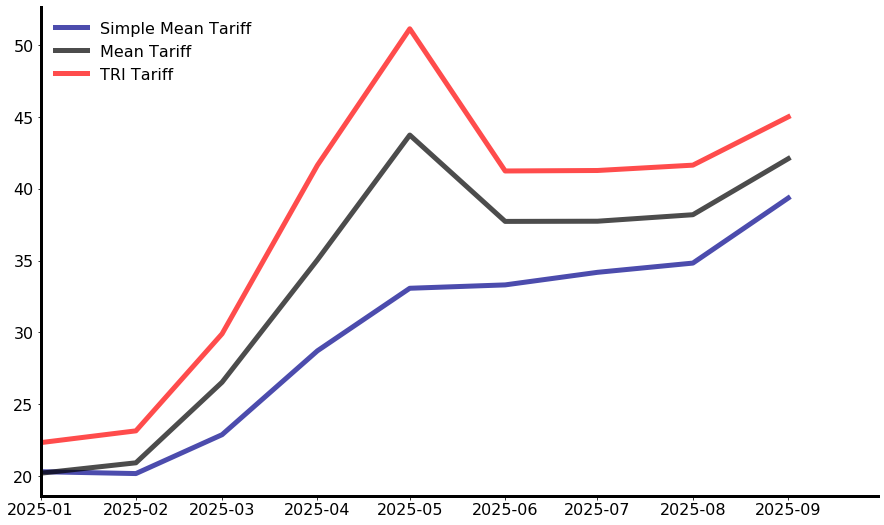

In [69]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["HS2"] == "61"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

# ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

# ax.set_ylim(top=13)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

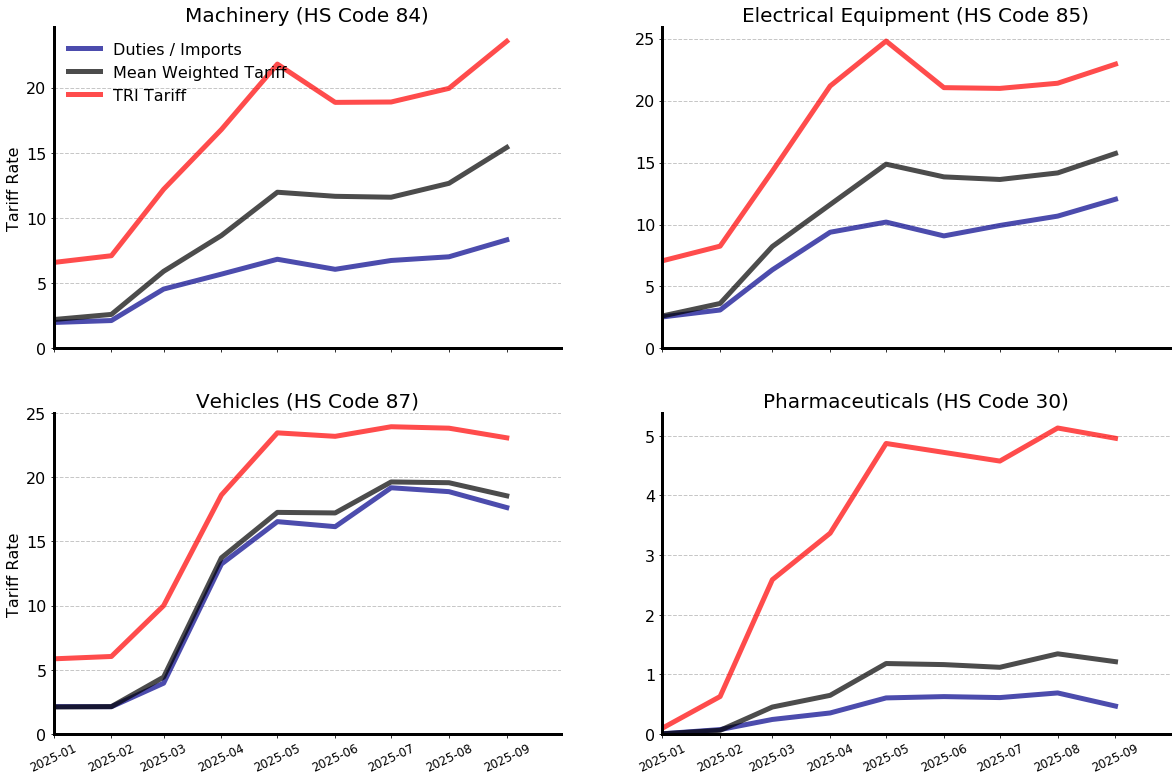

In [74]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, sharex = True, figsize = (20,13)) 

hscodes = ["84", "85", "87", "30"]

titles = ["Machinery", "Electrical Equipment", "Vehicles", "Pharmaceuticals"]

ax = ax.ravel() # Here is the trick here, ax is a 2 by 2 array. We want to work through it in a loop...so
                # one way to do this is to flatten stuff out, make it a 4 by 1 array. The ravel command 
                # does this...
    
for i, (ax, hscode) in enumerate(zip(ax, hscodes)):

    foo = metrics_df[metrics_df["HS2"] == hscode].copy()

    ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

    ax.set_title( titles[i] + " (HS Code " + foo["HS2"].iloc[0] + ")", fontsize = 20)

    ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

    ax.set_ylim(bottom=0)

    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax.spines["right"].set_visible(False)

    ax.spines["top"].set_visible(False)

    ax.spines["left"].set_linewidth(3)

    ax.spines["bottom"].set_linewidth(3)

    ax.grid(axis='y', linewidth=1, linestyle='--', alpha=0.7)

    if i == 0:  # Only show legend in first plot
        ax.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax.set_ylabel("Tariff Rate", fontsize=16)

    if i == 2:

        ax.set_ylabel("Tariff Rate", fontsize=16)


plt.savefig(figfile+"panel-top-sector-tariffs.png", bbox_inches = "tight")

plt.savefig(figfile+"panel-top-sector-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [88]:
target_date = "2025-09"
hscodes = ["84", "85", "87", "30"]
titles = ["Machinery", "Electrical Equipment", "Vehicles", "Pharmaceuticals"]

for hscode, title in zip(hscodes, titles):
    
    foo = metrics_df[metrics_df["HS2"] == hscode].copy()

    sqrtariff = foo[foo.date == target_date]["sqrtariff"].values[0]
    meanweighted = foo[foo.date == target_date]["meanweighted"].values[0]
    simplemean = foo[foo.date == target_date]["simplemean"].values[0]

    print(f"HS Code {hscode} - {title}:")
    print(f"  Weighted TRI Tariff: {sqrtariff:.2%}")
    print(" ")
    print(f"  Weighted Mean Tariff: {meanweighted:.2%}")        
    print(" ")
    print(f"  Simple Mean Tariff: {simplemean:.2%}")
    
    # Remove spaces from title for LaTeX command name
    title_clean = title.replace(" ", "")

    with open(texfile, 'a') as f:
        f.write(f'\\newcommand{{\\rmsValuetwofive{title_clean}}}{{{sqrtariff*100:.0f}}}\n')
        f.write(f'\\newcommand{{\\meanWeightedValuetwofive{title_clean}}}{{{meanweighted*100:.0f}}}\n')
        f.write(f'\\newcommand{{\\simpleMeanValuetwofive{title_clean}}}{{{simplemean*100:.0f}}}\n')


HS Code 84 - Machinery:
  Weighted TRI Tariff: 23.54%
 
  Weighted Mean Tariff: 15.41%
 
  Simple Mean Tariff: 8.33%
HS Code 85 - Electrical Equipment:
  Weighted TRI Tariff: 22.94%
 
  Weighted Mean Tariff: 15.73%
 
  Simple Mean Tariff: 12.04%
HS Code 87 - Vehicles:
  Weighted TRI Tariff: 23.06%
 
  Weighted Mean Tariff: 18.54%
 
  Simple Mean Tariff: 17.63%
HS Code 30 - Pharmaceuticals:
  Weighted TRI Tariff: 4.96%
 
  Weighted Mean Tariff: 1.21%
 
  Simple Mean Tariff: 0.47%


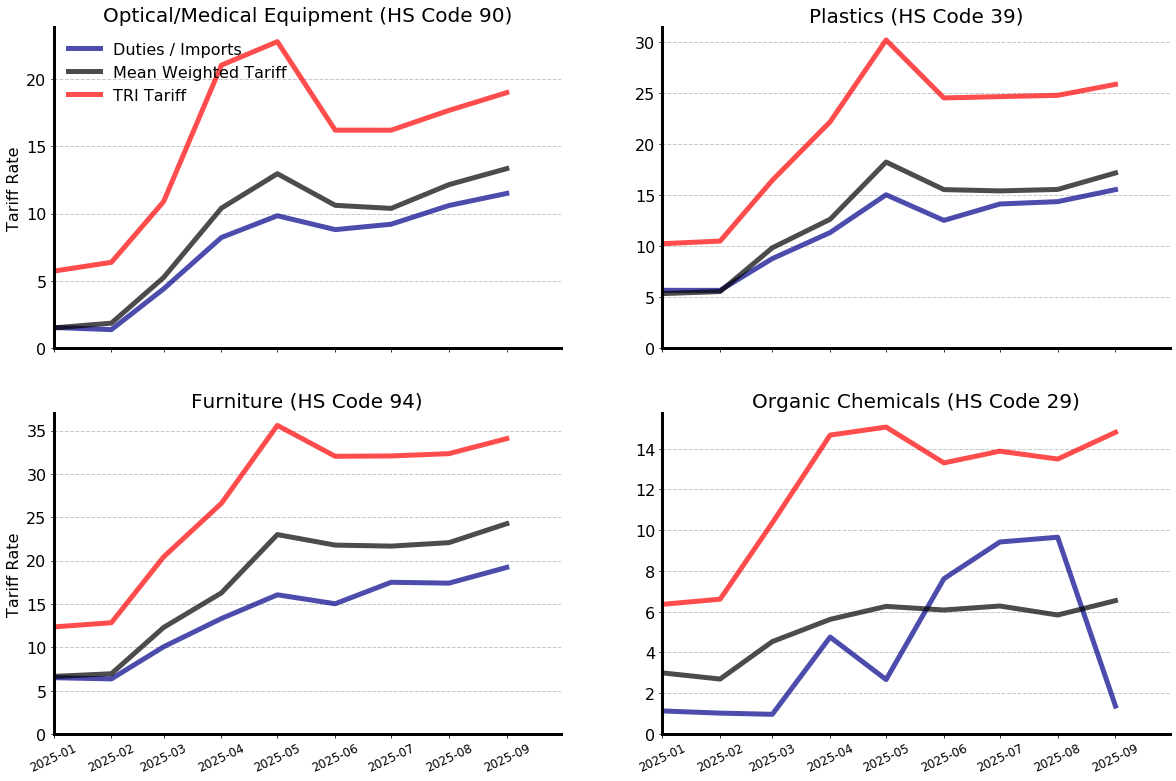

In [83]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, sharex = True, figsize = (20,13)) 

hscodes = ["90", "39", "94", "29"]

titles = ["Optical/Medical Equipment", "Plastics", "Furniture", "Organic Chemicals"]

ax = ax.ravel() # Here is the trick here, ax is a 2 by 2 array. We want to work through it in a loop...so
                # one way to do this is to flatten stuff out, make it a 4 by 1 array. The ravel command 
                # does this...
    
for i, (ax, hscode) in enumerate(zip(ax, hscodes)):

    foo = metrics_df[metrics_df["HS2"] == hscode].copy()

    ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

    ax.set_title( titles[i] + " (HS Code " + foo["HS2"].iloc[0] + ")", fontsize = 20)

    ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

    ax.set_ylim(bottom=0)

    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax.spines["right"].set_visible(False)

    ax.spines["top"].set_visible(False)

    ax.spines["left"].set_linewidth(3)

    ax.spines["bottom"].set_linewidth(3)

    ax.grid(axis='y', linewidth=1, linestyle='--', alpha=0.7)

    if i == 0:  # Only show legend in first plot
        ax.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax.set_ylabel("Tariff Rate", fontsize=16)

    if i == 2:

        ax.set_ylabel("Tariff Rate", fontsize=16)


# plt.savefig(figfile+"panel-top-sector-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"panel-top-sector-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
date_list = ["2025-09"]

metrics_df = create_tariff_metrics_by_date_sector(top_20products["HS2"].tolist(), date_list, weight_year="2024")

foo = pd.merge(left = metrics_df, right = top_20products[["HS2", "share"]], on = "HS2")

# Add a column to your dataframe
foo['HS2_name'] = foo['HS2'].map(hs2_names)

foo = foo[["HS2", "HS2_name", "sqrtariff", "meanweighted", "simplemean", "share"]].sort_values(by="sqrtariff", ascending=False).iloc[0:21]

foo[["sqrtariff", "meanweighted", "simplemean", "share"]] = 100*foo[["sqrtariff", "meanweighted", "simplemean", "share"]]

foo.rename(columns={
    "HS2_name": "HS2 Name",
    "sqrtariff": "TRI Tariff",
    "meanweighted": "Mean Weighted Tariff",
    "simplemean": "Simple Mean Tariff",
    "share": "Share of U.S. Imports"
}, inplace=True)

foo.to_latex(tabletex,
            index=False,
            escape=False,
            float_format="%.1f",
            caption='Tariff Metrics by Sector: September 2025',
            label='tab:tariff_sector')


Processing date: 2025-09, sector: 84
Processing date: 2025-09, sector: 85
Processing date: 2025-09, sector: 87
Processing date: 2025-09, sector: 30
Processing date: 2025-09, sector: 90
Processing date: 2025-09, sector: 39
Processing date: 2025-09, sector: 94
Processing date: 2025-09, sector: 29
Processing date: 2025-09, sector: 73
Processing date: 2025-09, sector: 61
Processing date: 2025-09, sector: 95
Processing date: 2025-09, sector: 88
Processing date: 2025-09, sector: 62
Processing date: 2025-09, sector: 40
Processing date: 2025-09, sector: 72
Processing date: 2025-09, sector: 22
Processing date: 2025-09, sector: 64
Processing date: 2025-09, sector: 76
Processing date: 2025-09, sector: 38
Processing date: 2025-09, sector: 08


In [117]:
foo.head(21)

,HS2,HS2 Name,TRI Tariff,Mean Weighted Tariff,Simple Mean Tariff,Share of U.S. Imports
8,73,Iron/Steel Articles,49.909704,42.430746,41.199362,1.519266
17,76,Aluminum,46.188319,40.395049,37.815703,0.816478
9,61,Knitted Apparel,45.005095,42.094661,39.358399,1.411484
12,62,Woven Apparel,40.881947,36.735202,31.559740,1.088959
14,72,Iron \& Steel,38.097754,31.045842,30.350082,0.974143
16,64,Footwear,34.949606,32.956939,31.365445,0.841194
6,94,Furniture,34.066590,24.254551,19.212800,2.062104
10,95,Toys \& Games,29.327379,27.469919,24.952997,1.259157
5,39,Plastics,25.844217,17.176581,15.540994,2.242392
13,40,Rubber,25.283741,18.661170,16.407756,1.050753
